## Train A Test A

### Classification

Category distribution:
0    10743
4     8938
3      768
2      159
5       55
1       39
6       32
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.93      0.91      0.92      2160
      Button       0.88      0.88      0.88         8
        Door       1.00      0.82      0.90        28
      Motion       0.94      0.81      0.87       153
      Socket       0.90      0.94      0.92      1776
 Temperature       1.00      0.80      0.89        15
   Vibration       1.00      0.86      0.92         7

    accuracy                           0.92      4147
   macro avg       0.95      0.86      0.90      4147
weighted avg       0.92      0.92      0.92      4147

Macro F1-Score: 0.9003


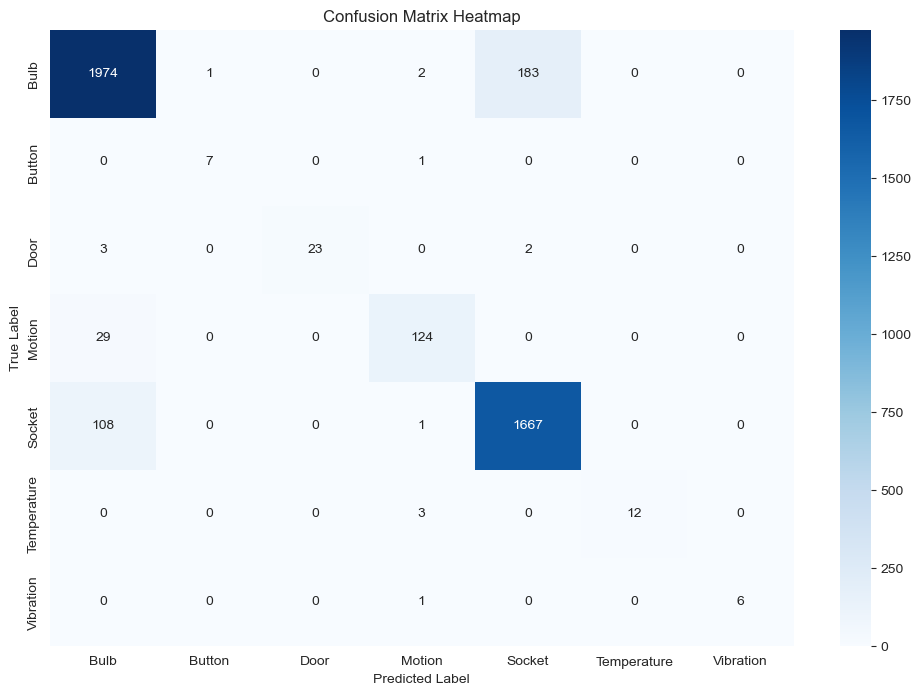

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
5     3393
15    2498
12    2429
14    2292
13    2246
8     2129
9     1582
10    1210
6     1038
7      864
11     706
1       65
20      55
0       39
2       39
3       37
16      36
4       32
19      21
17      19
18       4
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.88      0.88      0.88         8
        Aqara Door 1       0.77      0.77      0.77        13
        Aqara Door 2       0.67      0.29      0.40         7
        Aqara Motion       1.00      1.00      1.00         1
     Aqara Vibration       1.00      0.71      0.83         7
       Ledvance Bulb       0.80      0.85      0.83       682
Ledvance Smart+ Plug       0.82      0.73      0.78       215
    Ledvance Z3 Plug       0.66      0.82      0.73       169
           Moes Bulb       0.94      0.96      0.95       431
      Philips Lamp 1       0.67      0.46      0.55       320
      Philips Lamp 2       0.76      

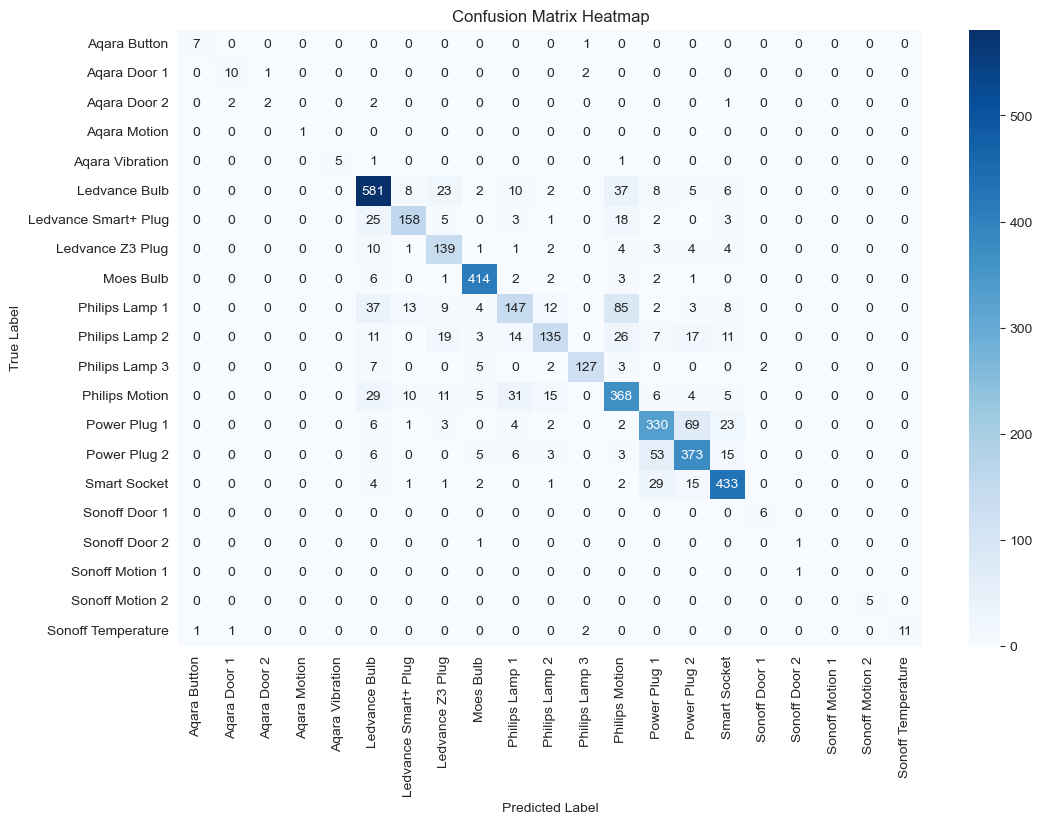

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
4    14254
0    11679
3     1628
1      318
5      186
2      137
6       36
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.91      0.89      0.90      2303
      Button       0.92      0.90      0.91        63
        Door       0.93      1.00      0.96        25
      Motion       0.95      0.89      0.92       345
      Socket       0.92      0.94      0.93      2859
 Temperature       0.95      0.93      0.94        41
   Vibration       1.00      0.58      0.74        12

    accuracy                           0.91      5648
   macro avg       0.94      0.88      0.90      5648
weighted avg       0.91      0.91      0.91      5648

Macro F1-Score: 0.8985


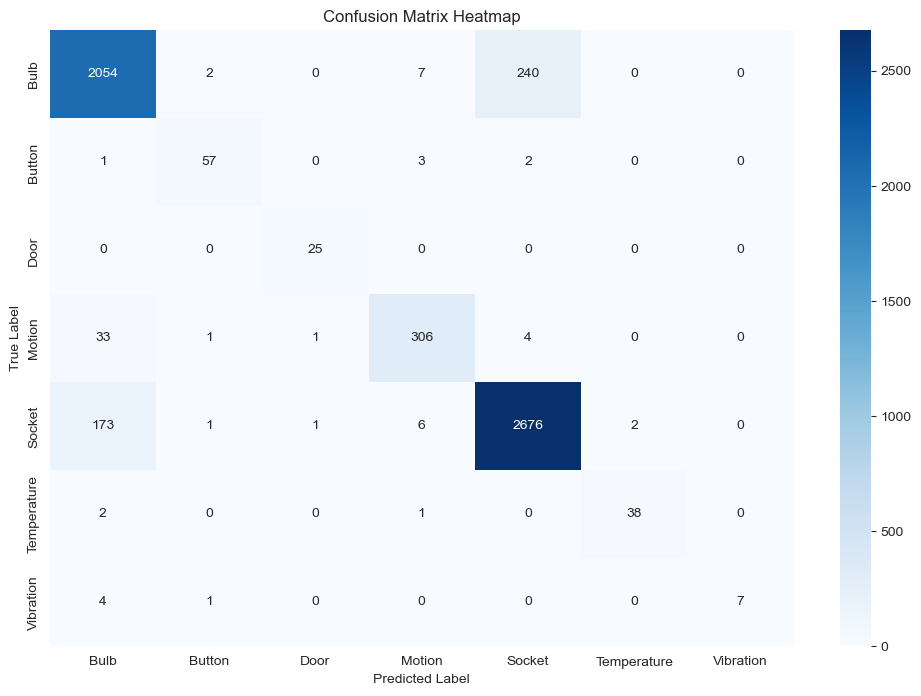

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
13    4337
15    3966
5     3779
14    3340
9     2674
11    1952
8     1928
7     1746
12    1389
10    1346
6      865
0      318
20     186
18     154
3       71
2       38
4       36
17      34
16      34
1       31
19      14
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.92      0.95      0.94        63
        Aqara Door 1       1.00      0.83      0.91         6
        Aqara Door 2       0.89      1.00      0.94         8
        Aqara Motion       1.00      0.94      0.97        18
     Aqara Vibration       1.00      0.42      0.59        12
       Ledvance Bulb       0.73      0.75      0.74       746
Ledvance Smart+ Plug       0.75      0.73      0.74       162
    Ledvance Z3 Plug       0.77      0.70      0.73       353
           Moes Bulb       0.87      0.87      0.87       367
      Philips Lamp 1       0.68      0.67      0.68       542
      Philips Lamp 2       0.69      

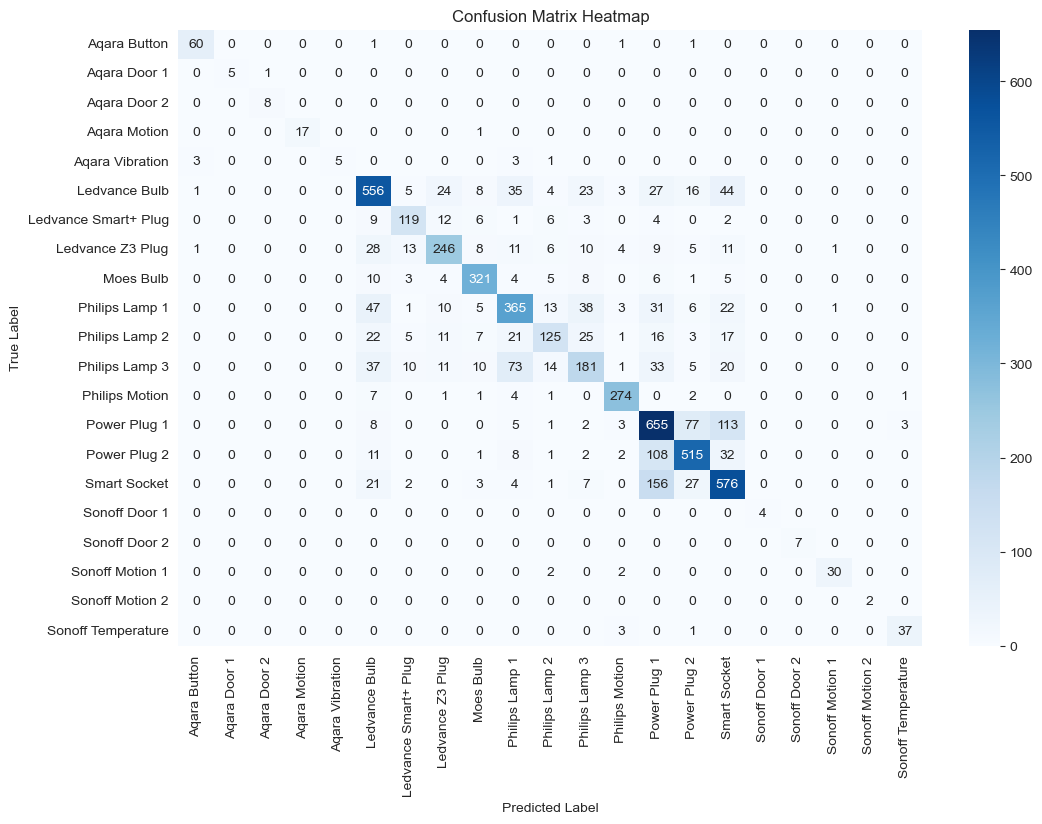

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
0    10743
4     8938
3      768
2      159
5       55
1       39
6       32
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.69      0.77      0.73     11679
      Button       0.00      0.00      0.00       318
        Door       0.17      0.09      0.12       137
      Motion       0.69      0.61      0.65      1628
      Socket       0.81      0.77      0.79     14254
 Temperature       0.83      0.22      0.34       186
   Vibration       0.00      0.00      0.00        36

    accuracy                           0.74     28238
   macro avg       0.46      0.35      0.38     28238
weighted avg       0.74      0.74      0.74     28238

Macro F1-Score: 0.3755


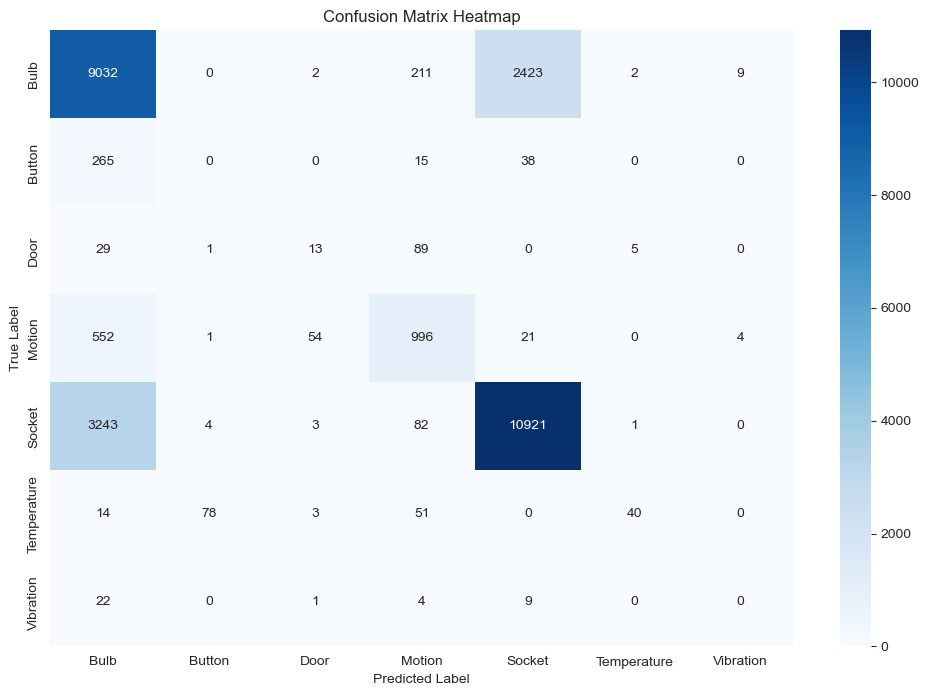

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
5     3393
15    2498
12    2429
14    2292
13    2246
8     2129
9     1582
10    1210
6     1038
7      864
11     706
1       65
20      55
0       39
2       39
3       37
16      36
4       32
19      21
17      19
18       4
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.01      0.00      0.00       318
        Aqara Door 1       0.44      0.13      0.20        31
        Aqara Door 2       0.00      0.00      0.00        38
        Aqara Motion       0.45      0.07      0.12        71
     Aqara Vibration       0.00      0.00      0.00        36
       Ledvance Bulb       0.48      0.55      0.52      3779
Ledvance Smart+ Plug       0.15      0.10      0.12       865
    Ledvance Z3 Plug       0.31      0.32      0.32      1746
           Moes Bulb       0.47      0.47      0.47      1928
      Philips Lamp 1       0.27      0.17      0.21      2674
      Philips Lamp 2       0.14      

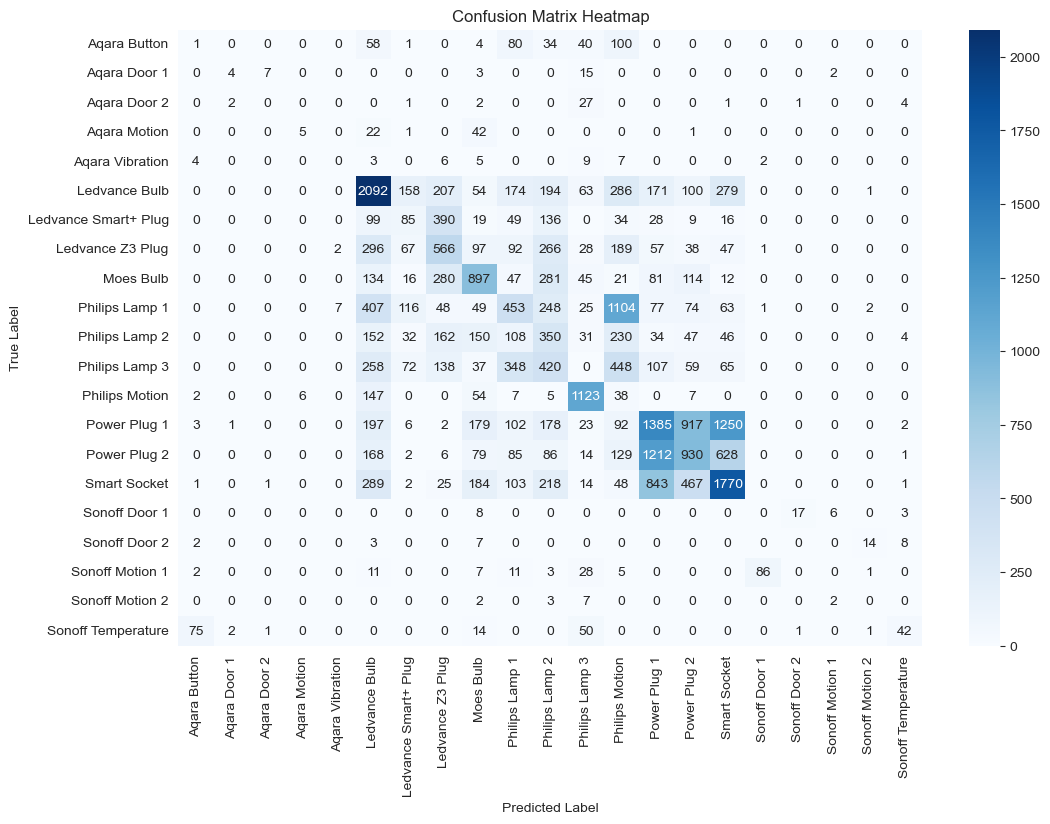

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
4    14254
0    11679
3     1628
1      318
5      186
2      137
6       36
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.83      0.82      0.83     10743
      Button       0.00      0.00      0.00        39
        Door       0.73      0.25      0.37       159
      Motion       0.67      0.46      0.54       768
      Socket       0.81      0.84      0.82      8938
 Temperature       0.33      0.91      0.49        55
   Vibration       0.00      0.00      0.00        32

    accuracy                           0.81     20734
   macro avg       0.48      0.47      0.44     20734
weighted avg       0.81      0.81      0.81     20734

Macro F1-Score: 0.4359


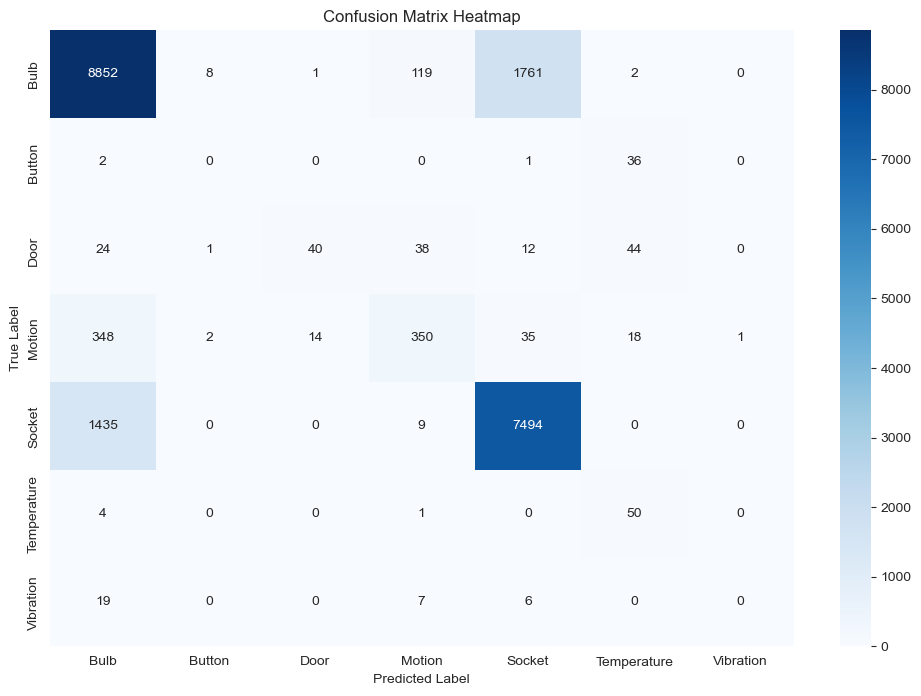

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
13    4337
15    3966
5     3779
14    3340
9     2674
11    1952
8     1928
7     1746
12    1389
10    1346
6      865
0      318
20     186
18     154
3       71
2       38
4       36
17      34
16      34
1       31
19      14
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.00      0.00      0.00        39
        Aqara Door 1       0.00      0.00      0.00        65
        Aqara Door 2       0.25      0.62      0.36        39
        Aqara Motion       0.92      0.32      0.48        37
     Aqara Vibration       0.00      0.00      0.00        32
       Ledvance Bulb       0.54      0.62      0.58      3393
Ledvance Smart+ Plug       0.38      0.15      0.21      1038
    Ledvance Z3 Plug       0.35      0.40      0.37       864
           Moes Bulb       0.73      0.40      0.52      2129
      Philips Lamp 1       0.20      0.40      0.27      1582
      Philips Lamp 2       0.16      

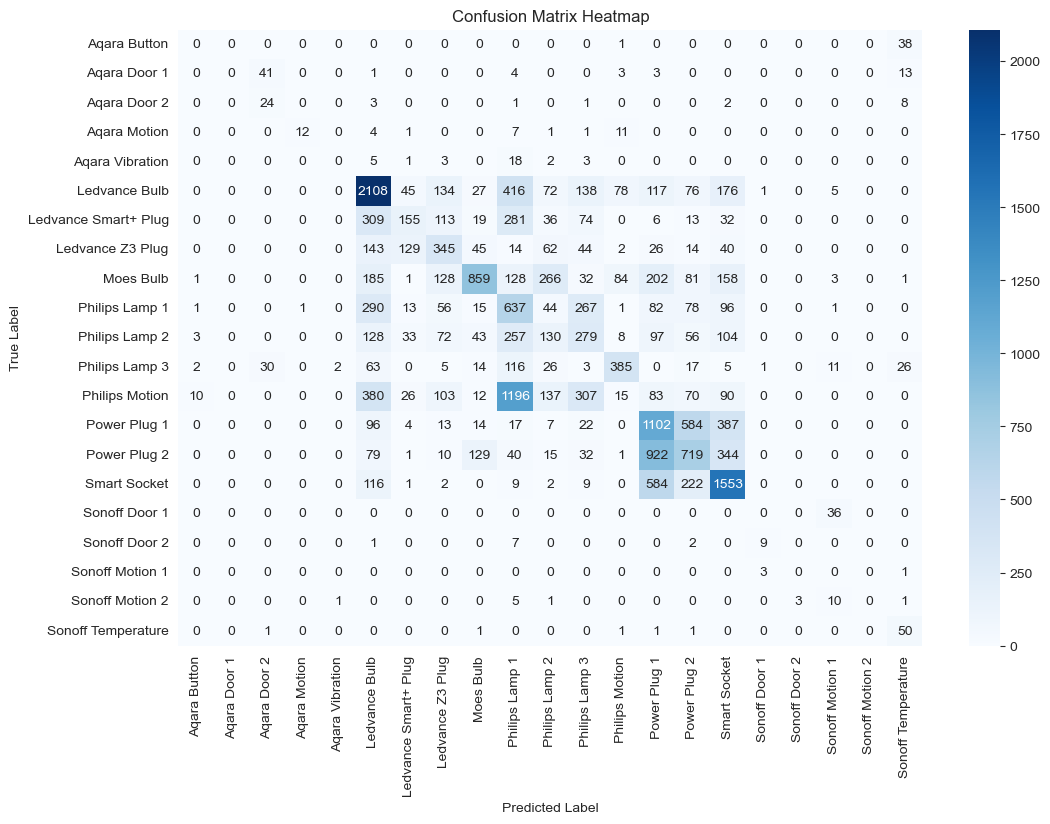

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
